In [1]:
import matplotlib.pyplot as plt

In [2]:
#Define parameters

ph = 0.4
pt = 1 - ph
gamma = 1.0
theta = 1e-9
states = list(range(101))

In [3]:
#Building MDP

mdp = {s: {} for s in states}

for s in states:
    if s == 0 or s == 100:
        continue
    for a in range(1, min(s, 100 - s) + 1):
        mdp[s][a] = [
            (ph, s + a, int(s + a == 100)),   # win
            (pt, s - a, int(s - a == 100))    # lose
        ]

In [4]:
#Value iteration

V = [0.0] * 101
V[100] = 1.0

while True:
    delta = 0
    Vnew = V.copy()

    for s in range(1, 100):
        best = 0.0
        for a in mdp[s]:
            transitions = mdp[s][a]
            value = 0
            for (p, s2, r) in transitions:
                value += p * (r + gamma * V[s2])
            best = max(best, value)

        Vnew[s] = best
        delta = max(delta, abs(Vnew[s] - V[s]))

    V = Vnew
    if delta < theta:
        break

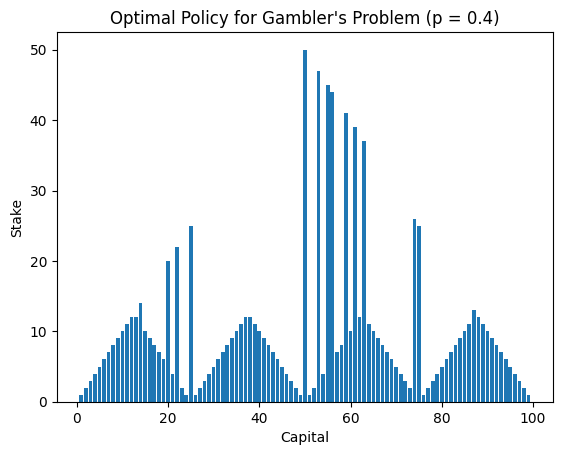

In [5]:
#Policy extraction

policy = [0] * 101

for s in range(1, 100):
    best_val = -1
    best_act = 0

    for a in mdp[s]:
        value = 0
        for (p, s2, r) in mdp[s][a]:
            value += p * (r + gamma * V[s2])

        if value > best_val:
            best_val = value
            best_act = a

    policy[s] = best_act

plt.bar(range(1, 100), policy[1:100])
plt.xlabel("Capital")
plt.ylabel("Stake")
plt.title("Optimal Policy for Gambler's Problem (p = 0.4)")
plt.show()